In [1]:
import pandas as pd
import numpy as np 
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn import datasets

In [2]:
pd.set_option('display.float_format', lambda x: '%.1f' % x)

In [3]:
housing_df = pd.read_csv("C:/Users/leste/OneDrive/Desktop/Microsoft VS Code/Github/Data-Analytics-Projects-/Data Files/Housing Dataset.csv")


In [4]:
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.0,20640.0,20640.0,20640.0,20433.0,20640.0,20640.0,20640.0,20640.0
mean,-119.6,35.6,28.6,2635.8,537.9,1425.5,499.5,3.9,206855.8
std,2.0,2.1,12.6,2181.6,421.4,1132.5,382.3,1.9,115395.6
min,-124.3,32.5,1.0,2.0,1.0,3.0,1.0,0.5,14999.0
25%,-121.8,33.9,18.0,1447.8,296.0,787.0,280.0,2.6,119600.0
50%,-118.5,34.3,29.0,2127.0,435.0,1166.0,409.0,3.5,179700.0
75%,-118.0,37.7,37.0,3148.0,647.0,1725.0,605.0,4.7,264725.0
max,-114.3,42.0,52.0,39320.0,6445.0,35682.0,6082.0,15.0,500001.0


In [5]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [30]:
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.2,37.9,41.0,880.0,129.0,322.0,126.0,8.3,452600.0,NEAR BAY
1,-122.2,37.9,21.0,7099.0,1106.0,2401.0,1138.0,8.3,358500.0,NEAR BAY
2,-122.2,37.9,52.0,1467.0,190.0,496.0,177.0,7.3,352100.0,NEAR BAY
3,-122.2,37.9,52.0,1274.0,235.0,558.0,219.0,5.6,341300.0,NEAR BAY
4,-122.2,37.9,52.0,1627.0,280.0,565.0,259.0,3.8,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.1,39.5,25.0,1665.0,374.0,845.0,330.0,1.6,78100.0,INLAND
20636,-121.2,39.5,18.0,697.0,150.0,356.0,114.0,2.6,77100.0,INLAND
20637,-121.2,39.4,17.0,2254.0,485.0,1007.0,433.0,1.7,92300.0,INLAND
20638,-121.3,39.4,18.0,1860.0,409.0,741.0,349.0,1.9,84700.0,INLAND


### Univariate Regression

> Predicting the housing median value

> Using the feature population

Text(0.5, 1.0, 'Distribution of Median House Value')

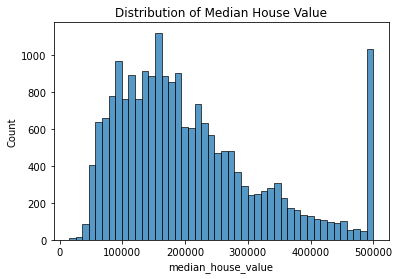

In [7]:
sns.histplot(x = "median_house_value", data = housing_df)
plt.title("Distribution of Median House Value")

In [8]:
housing_df[housing_df["population"] > 25000]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
9880,-121.8,36.6,11.0,32627.0,6445.0,28566.0,6082.0,2.3,118800.0,<1H OCEAN
15360,-117.4,33.4,14.0,25135.0,4819.0,35682.0,4769.0,2.6,134400.0,<1H OCEAN


<AxesSubplot: ylabel='median_house_value'>

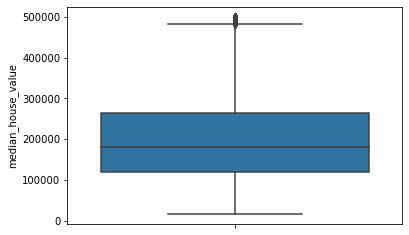

In [9]:
sns.boxplot(y="median_house_value", data = housing_df)

In [26]:
x_train , y_train = housing_df['population'] , housing_df['median_house_value']

In [16]:
x_train.shape
(f"No. of training samples m: {x_train.shape[0]}")

'No. of training samples m: 20640'

In [21]:
i = 1
x_i = x_train.iloc[i]
y_i = y_train.iloc[i]

In [23]:
x_i , y_i

(population   2401.0
 Name: 1, dtype: float64,
 median_house_value   358500.0
 Name: 1, dtype: float64)

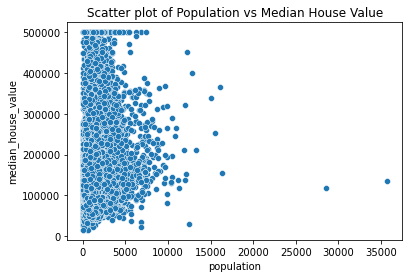

In [32]:
sns.scatterplot(x = x_train, y = y_train)
plt.title("Scatter plot of Population vs Median House Value")
plt.show()

In [53]:
# According to the linear Regression function, f(x) = wx + b, where w is the weight and b is the bias. My current feature is population and my target is median house value. Assuming my population increases by 1,000 people, I want to predict how much the median house value will increase.
w = 5
b = 0 #Assuming my population is 0 
f = w * x_i + b

In [54]:
f

population   12005.0
Name: 1, dtype: float64

In [55]:
def compute_regression_output(x,w,b):

    m = x.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = w * x[i] + b
    return f_wb

<AxesSubplot: xlabel='population', ylabel='median_house_value'>

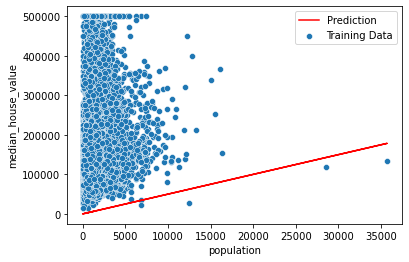

In [56]:
plt.plot(x_train, compute_regression_output(x_train,w,b), color = 'r', label = "Prediction")
sns.scatterplot(x = x_train, y = y_train, label = "Training Data")

In [58]:
y_df = pd.DataFrame(y_train)


In [59]:
# computing cost function J_wb assuming b = 0

y_df["prediction_1"] = compute_regression_output(x_train,w,b)

In [ ]:
y_df

,median_house_value,prediction_1
0,452600.0,1610.0
1,358500.0,12005.0
2,352100.0,2480.0
3,341300.0,2790.0
4,342200.0,2825.0
...,...,...
20635,78100.0,4225.0
20636,77100.0,1780.0
20637,92300.0,5035.0
20638,84700.0,3705.0


In [ ]:
def compute_cost(x,y, w, b):
    m = x.shape[0]
    cost = 0.0
    for i in range(m):
        cost += (y["prediction_1"]- y["median_house_value"]) ** 2
    total_cost = cost / (2)
    return total_cost

In [79]:
y_df['cost_1'] = compute_cost(x_train, y_df, w, b)

In [73]:
y_df

,median_house_value,prediction_1,cost_1
0,452600.0,1610.0,26635610579.6
1,358500.0,12005.0,26635610579.6
2,352100.0,2480.0,26635610579.6
3,341300.0,2790.0,26635610579.6
4,342200.0,2825.0,26635610579.6
...,...,...,...
20635,78100.0,4225.0,26635610579.6
20636,77100.0,1780.0,26635610579.6
20637,92300.0,5035.0,26635610579.6
20638,84700.0,3705.0,26635610579.6
